# Surface-class time series — Barrow strip

Loads the ERA5 archive and the land–sea mask **once**, classifies every cell,
and reduces the chosen seasons to `(day-of-season, class)` arrays. Each figure
cell then draws from that in-memory state in about a second.

`build_series` accumulates **all four quantities in a single streaming pass**,
so every figure below is already paid for once the load cell finishes — there is
no `--variable` to choose here, and no reason to reload when you want a
different one.

Everything comes from `plot_surface_class_timeseries.py`; this notebook holds no
analysis code of its own, so the two cannot drift apart. Autoreload is on, so
editing the module and re-running a figure cell picks up the change.

| Cell | What it does |
|---|---|
| Load | `prepare()` → an `Analysis` holding the classified, season-collapsed arrays |
| Report | mean area share per surface class |
| Figures | DLR, LWP, IWP, liquid fraction — one cell each |

Alongside the five surface classes, every figure carries a sixth curve for the
**single ERA5 grid cell containing the DOE ARM facility at Utqiaġvik**
(71.323° N, 156.609° W), for direct comparison against the ground
observations there. It is drawn dashed and black.

That cell is *not* a sixth surface class. The five classes partition the domain
and their areas sum to 100%; the ARM cell already sits inside one of them, so it
is carried as an overlay on the top panel and kept out of the area panel. The
load report prints which class it falls in, and how far the cell centre is from
the facility.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import plot_surface_class_timeseries as sct

# open_mfdataset warns about join/compat defaults changing; the module pins both
# explicitly, so the warning is noise here.
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use --dpi

# Set to a directory to write PNGs as well as display them; None displays only.
# SAVE_DIR = None
SAVE_DIR = Path("figures/SurfaceClass")

## Load the data

The slow cell. `prepare()` takes the same options as the command line, by
keyword — `region`, `years`, `season_start`, `season_end`, `storage`,
`data_root`, `mask_grid`, `lsm_tol`, `open_ocean_max_siconc`,
`sea_ice_min_siconc`, `land_max_siconc`, `lwp_threshold`, `iwp_threshold`,
`min_cloud_fraction`, `trace_threshold`, `min_class_area`, `smooth`,
`area_style`, `min_season_coverage`, `block_hours`, `dpi`.

All condensate thresholds are **g m⁻²**. Anything you leave out keeps its
command-line default.

In [2]:
A = sct.prepare(
    region="barrow",
    years=tuple(range(2011, 2026)),   # season START years
    season_start=(8, 1),
    season_end=(3, 31),
    lwp_threshold = 0.031,                   # g m-2, liquid PRESENT test
    iwp_threshold= 0.031,                # g m-2, ice PRESENT test
    trace_threshold=0.03,             # g m-2, zeroes trace hours before the
                                      # lwp/iwp magnitude means
    min_cloud_fraction = 0.99,        # minimum cloud fraction for a grid cell to be
                                      # considered cloudy
    lsm_tol = 0.01,                   # land-sea mask tolerance for 
                                      # classifying a grid cell as land or sea
    open_ocean_max_siconc = 0.05,  # maximum sea ice concentration for a grid cell to be
                                      # considered open ocean
    sea_ice_min_siconc = 0.95,      # minimum sea ice concentration for a grid cell to be
                                      # considered sea ice
    smooth = 5,                         # running-mean window in days
    storage="local",
    dpi = 350,
)

Surface-class time series
  Source     : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow
  Grid       : 41 x 61 cells, 103,752 time steps
  Season     : 08-01 to 03-31  (wraps the new year)
  Classes    : lsm tol 0.01 | open ocean < 0.05 | pack ice > 0.95

  Seasons found (18), coverage of the 244-day window:
    1999/2000:  37.3%   (below --min-season-coverage)
    2000/2001:  99.6%
    2001/2002:  62.7%
    2011/2012: 100.0%
    2012/2013:  99.6%
    2013/2014:  29.5%   (below --min-season-coverage)
    2014/2015:  99.6%
    2015/2016: 100.0%
    2016/2017:  99.6%
    2017/2018:  95.1%
    2018/2019:  99.6%
    2019/2020: 100.0%
    2020/2021:  99.6%
    2021/2022:  99.6%
    2022/2023:  99.6%
    2023/2024: 100.0%
    2024/2025:  99.6%
    2025/2026:  99.6%

  Reading 15 season(s): [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]



  !! Requested season(s) [2013] cover less than 60% of the window and are included anyway because you named them.


## Surface-class area shares

Optional — the figures do not depend on it. A class holding less than
`--min-class-area` percent of the domain has its line blanked in the figures,
so this tells you which lines to expect.

This also reports the ARM site cell: the nearest cell centre and its offset from
the facility, its share of the domain (one cell, so ~0.04% — a sanity check
that exactly one cell was picked, not a meaningful area), and which surface
class it classifies as over the season.

In [3]:
sct.print_report(A)


  Mean area share over the season window:
    Land                  0.69%
    Coastal (mixed)      11.66%
    Open ocean           21.54%
    Marginal ice zone    20.07%
    Sea ice              46.05%

  Utqiagvik (ARM site): facility at 71.323 N, -156.609 E
    nearest cell centre  : 71.250 N, -156.500 E  (offset -0.073, +0.109 deg)
    share of the domain  : 0.050%  (one cell; not stacked)
    the cell classifies as, over the window:
      Coastal (mixed)     100.00%


## Figures

Each cell is self-contained: it reads `A` and returns a `matplotlib` figure.
Pass `out_dir=` to save. Nothing below re-reads the archive.

Both panels share an x axis: the quantity by surface class on top, the area
share each class occupies on the bottom.

The dashed black curve is the ARM site cell. Because it is a single cell it is
exempt from the `min_class_area` blanking that applies to the five classes —
it would otherwise be blanked everywhere.

### 1. Downwelling longwave

The surface-energy-budget term the classification is meant to explain: does open
ocean sit under a systematically different DLR than pack ice?

  -> figures/SurfaceClass/barrow_surfaceclass_dlr_mean2011-2025.png


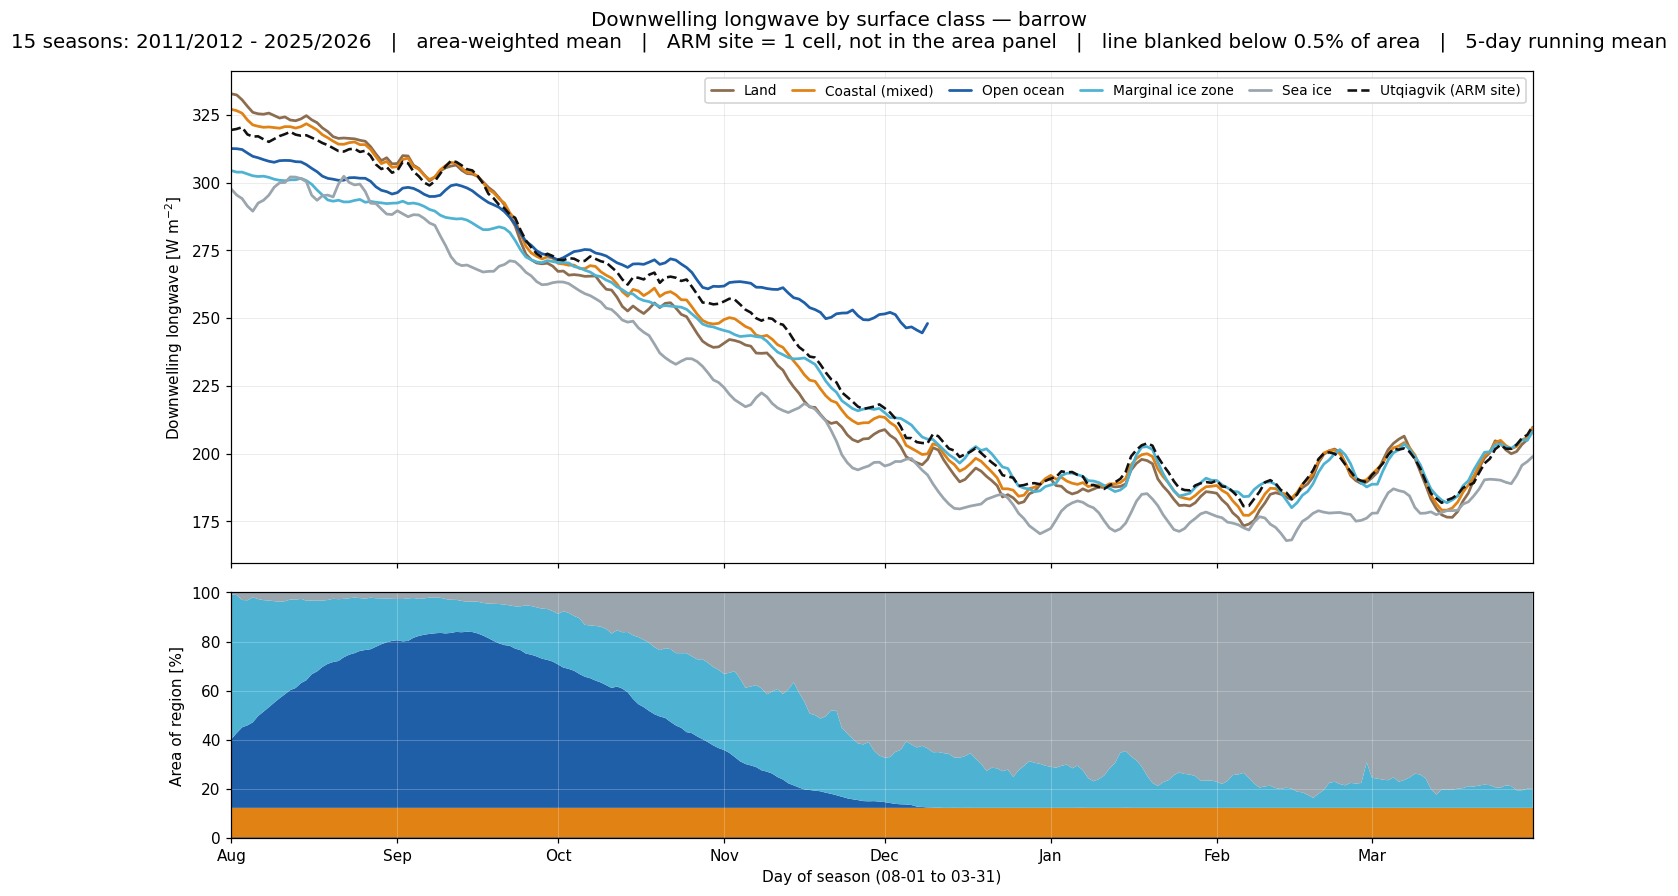

In [4]:
sct.fig_dlr(A, out_dir=SAVE_DIR);

### 2. Liquid water path

Area-weighted **mean** magnitude, with hours at or below `trace_threshold`
zeroed first. A mean, not a median — so it is not directly comparable to
`plot_monthly_lwp_maps.py`, which reports a median per cell.

  -> figures/SurfaceClass/barrow_surfaceclass_lwp_mean2011-2025.png


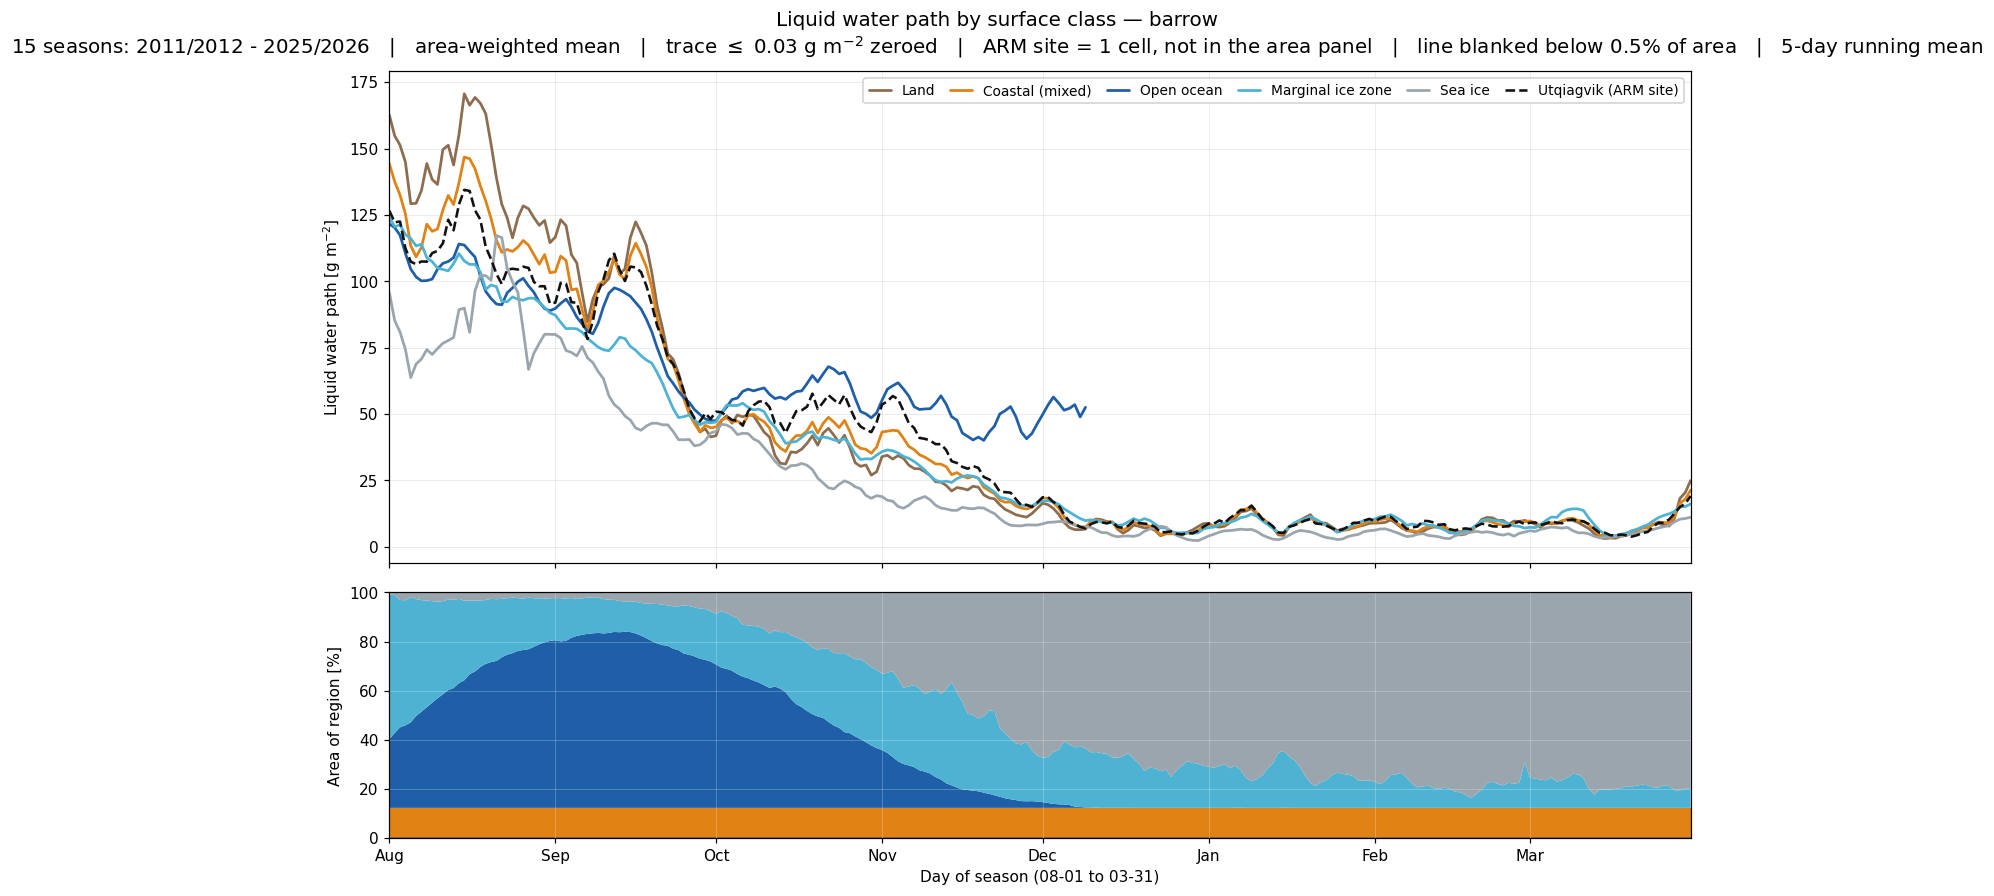

In [5]:
sct.fig_lwp(A, out_dir=SAVE_DIR);

### 3. Ice water path

Same treatment as LWP. Remember this is ERA5's `tciw`, suspended cloud ice only
— falling snow lives in `tcsw` and is not included.

  -> figures/SurfaceClass/barrow_surfaceclass_iwp_mean2011-2025.png


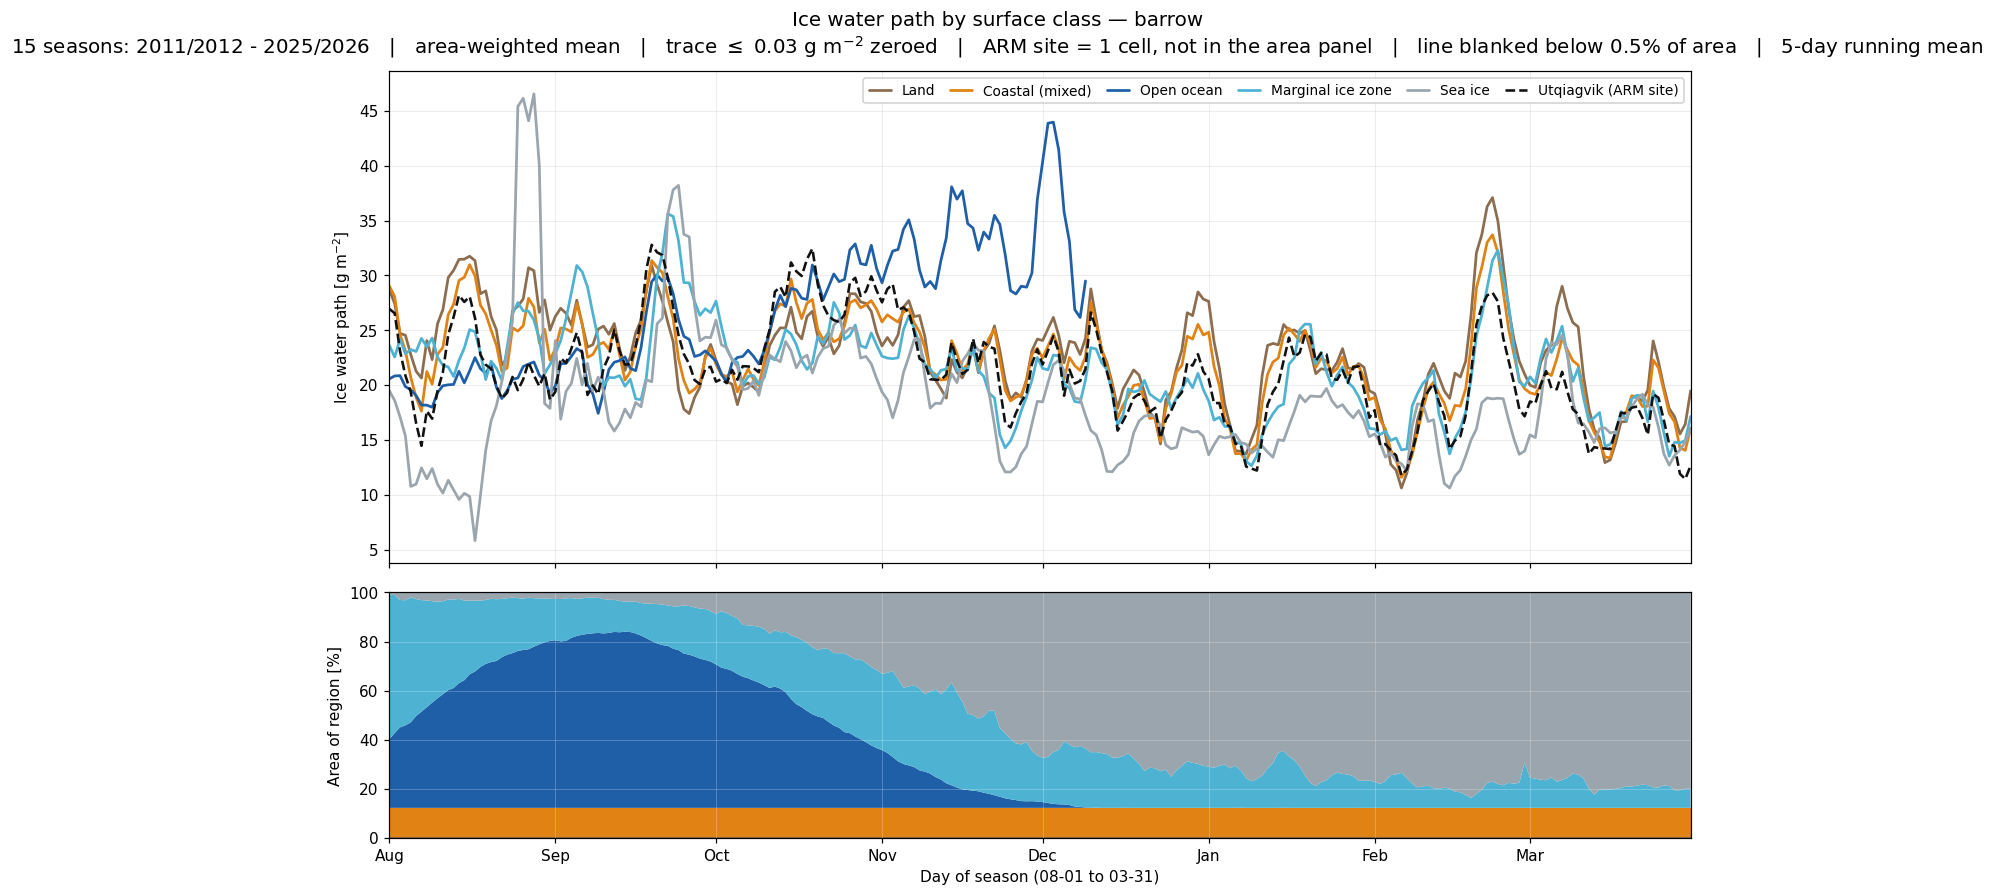

In [6]:
sct.fig_iwp(A, out_dir=SAVE_DIR);

### 4. Cloudy scenes containing liquid

A ratio rather than a mean: of the cell-hours that are cloudy, the share whose
LWP exceeds `lwp_threshold`, per surface class.

  -> figures/SurfaceClass/barrow_surfaceclass_liquid_fraction_mean2011-2025.png


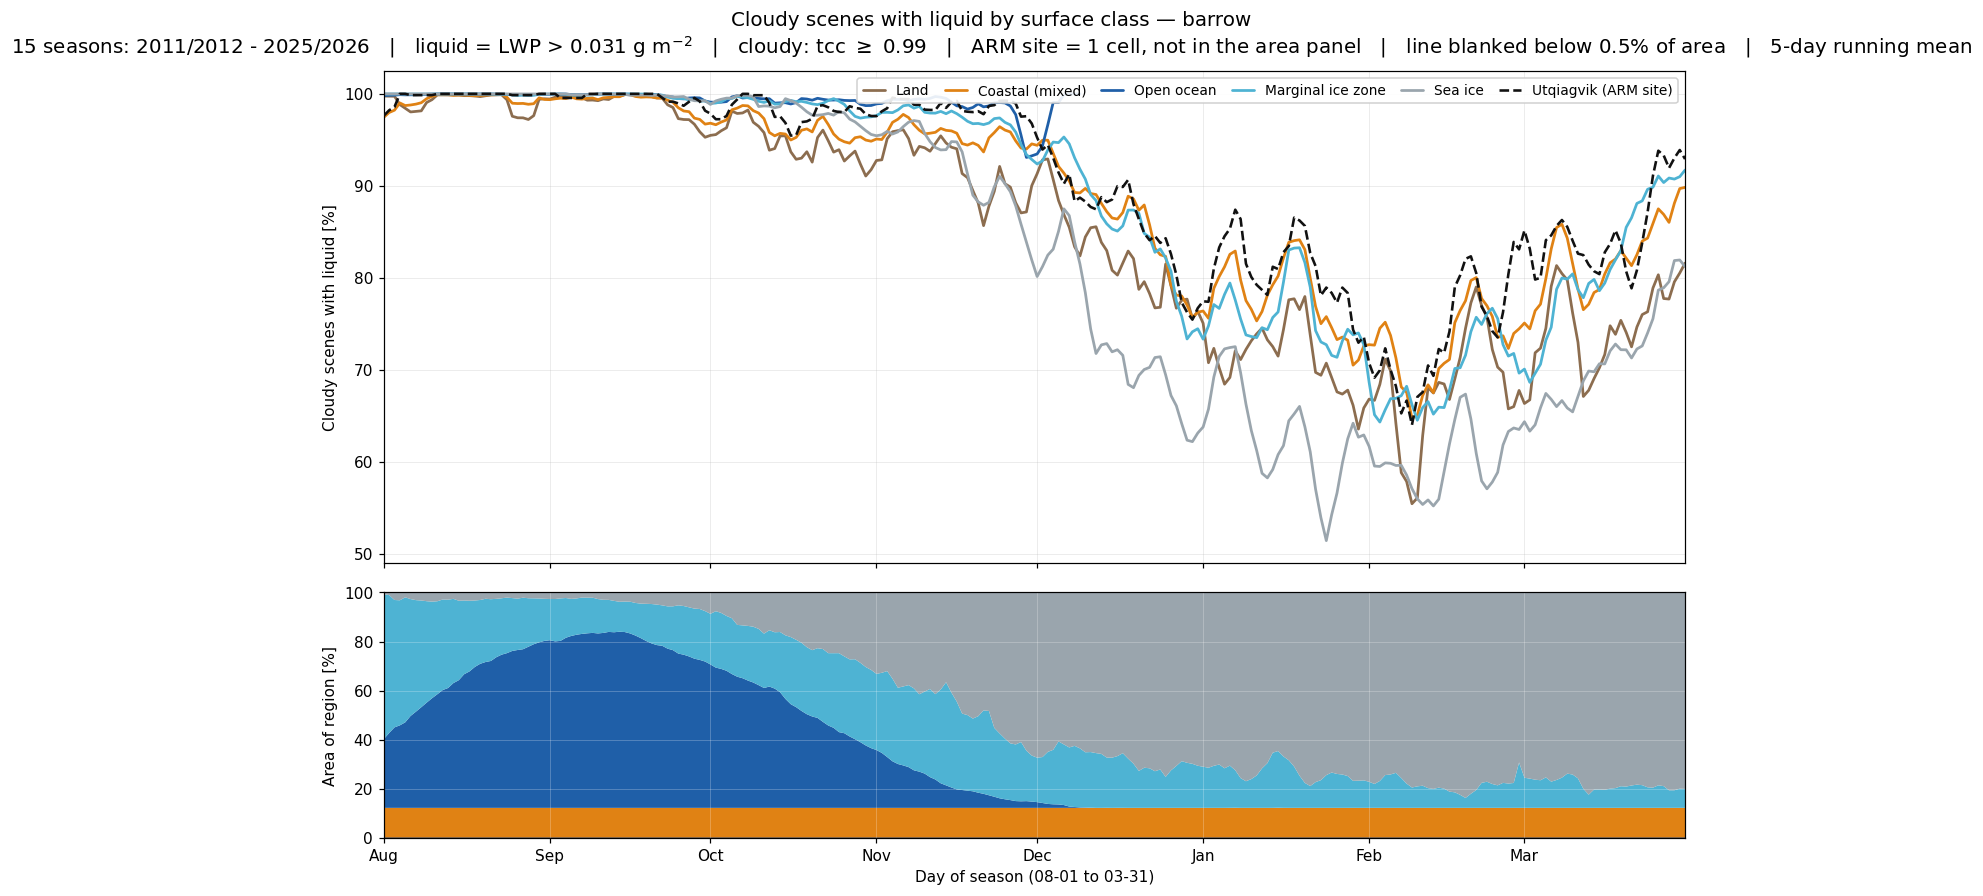

In [7]:
sct.fig_liquid_fraction(A, out_dir=SAVE_DIR);

## Monthly summary across all six series

The four figures above are daily time series. These three collapse them to one
number per month per series, so the six can be compared side by side.

**Two nested medians**, in this order: within a season, the median over the days
of the month; then across seasons, the median of those. Season-first matters
here — December 2022 held 50% marginal ice where 2025 held 3%, and collapsing
seasons first would let that one year set the month.

The same `min_class_area` blanking the line figures use is applied before the
medians, so a class too small for its daily mean to mean anything does not
contribute to its monthly value either. That is why **Land is absent from every
panel** — it never clears 0.5% of this domain. The ARM cell is exempt, being one
cell by construction.

### Grouped bars

Six bars per month, four panels. Every bar shares a baseline of zero, so any bar
can be compared to any other, within a month or across months.

  -> figures/SurfaceClass/barrow_surfaceclass_monthly_grouped_mean2011-2025.png


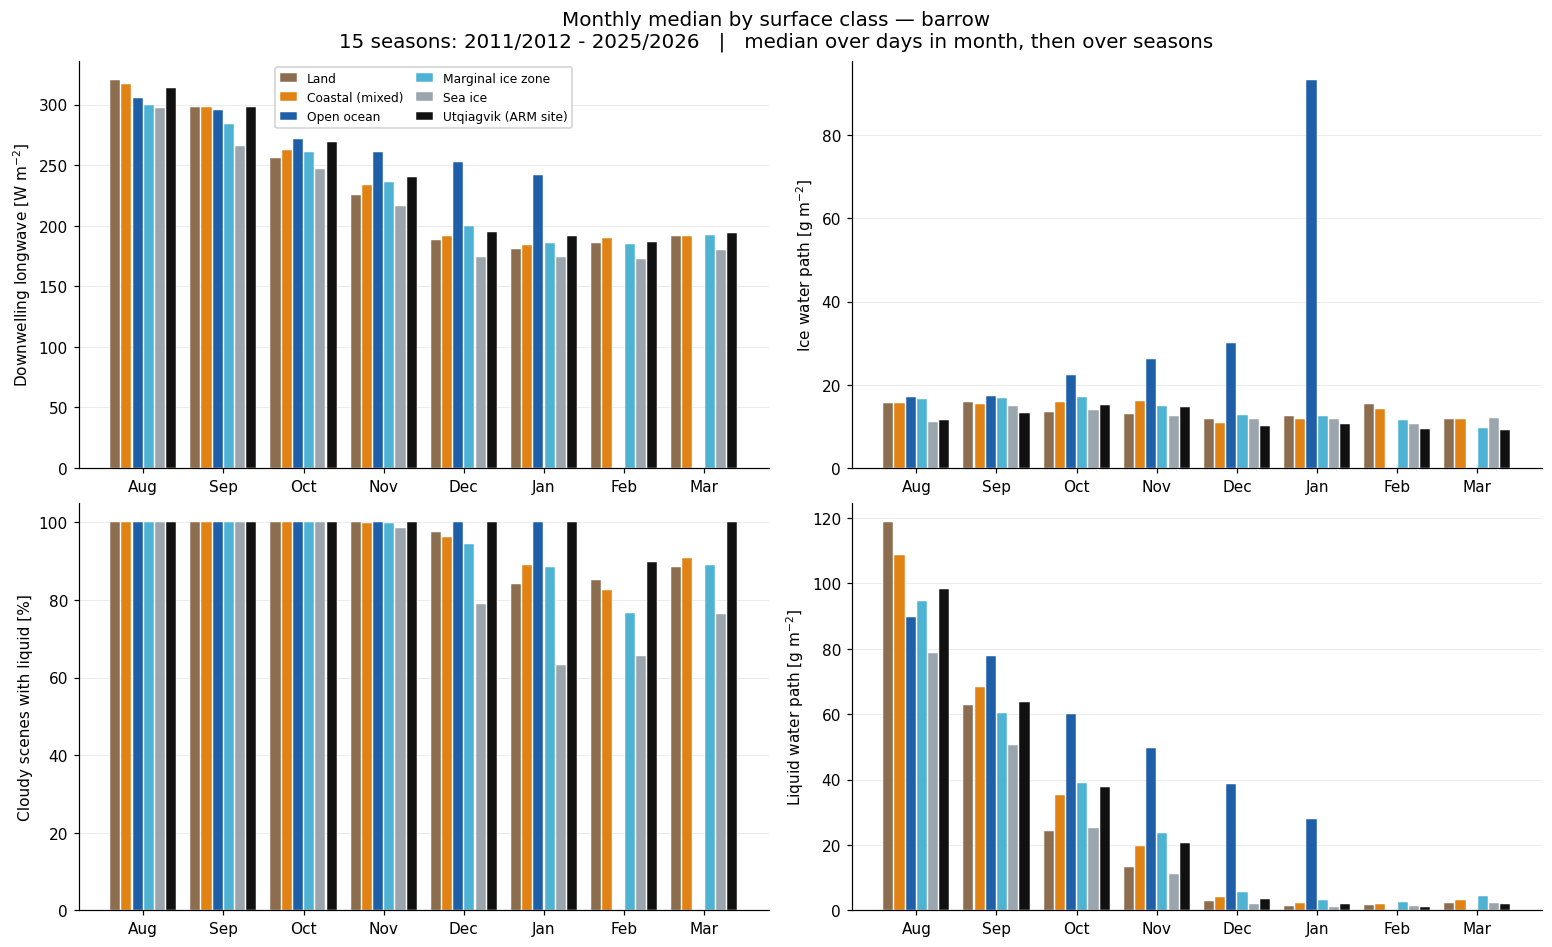

In [8]:
sct.fig_monthly_grouped(A, out_dir=SAVE_DIR);

### Stacked bars — shown for comparison, not for reading

Requested as an alternative, and drawn faithfully, but it should not be used to
read anything off. Two problems, both visible in the output:

- **The total is not a quantity.** Stacking asserts the segments add to a
  meaningful whole. These six numbers are independent estimates of the *same*
  variable over different subsets of the domain, so their sum is meaningless —
  the DLR panel tops out near 1300 W m⁻², which is not a longwave flux that
  exists anywhere. The bar height is an artefact of how many classes happen to
  clear the area threshold, which is why the bars drop sharply at January: open
  ocean vanishes and its segment simply stops being added.
- **Only the bottom segment has a baseline.** Coastal sits on zero and can be
  read; every segment above it floats on the sum of those below, so comparing
  sea ice between October and January means comparing two segments that start at
  different heights. Human eyes are poor at that.

Stacking is the right encoding when the parts genuinely compose a whole — which
is exactly what the *area share* panel in the figures above does, and why that
one is a legitimate stack.

  -> figures/SurfaceClass/barrow_surfaceclass_monthly_stacked_mean2011-2025.png


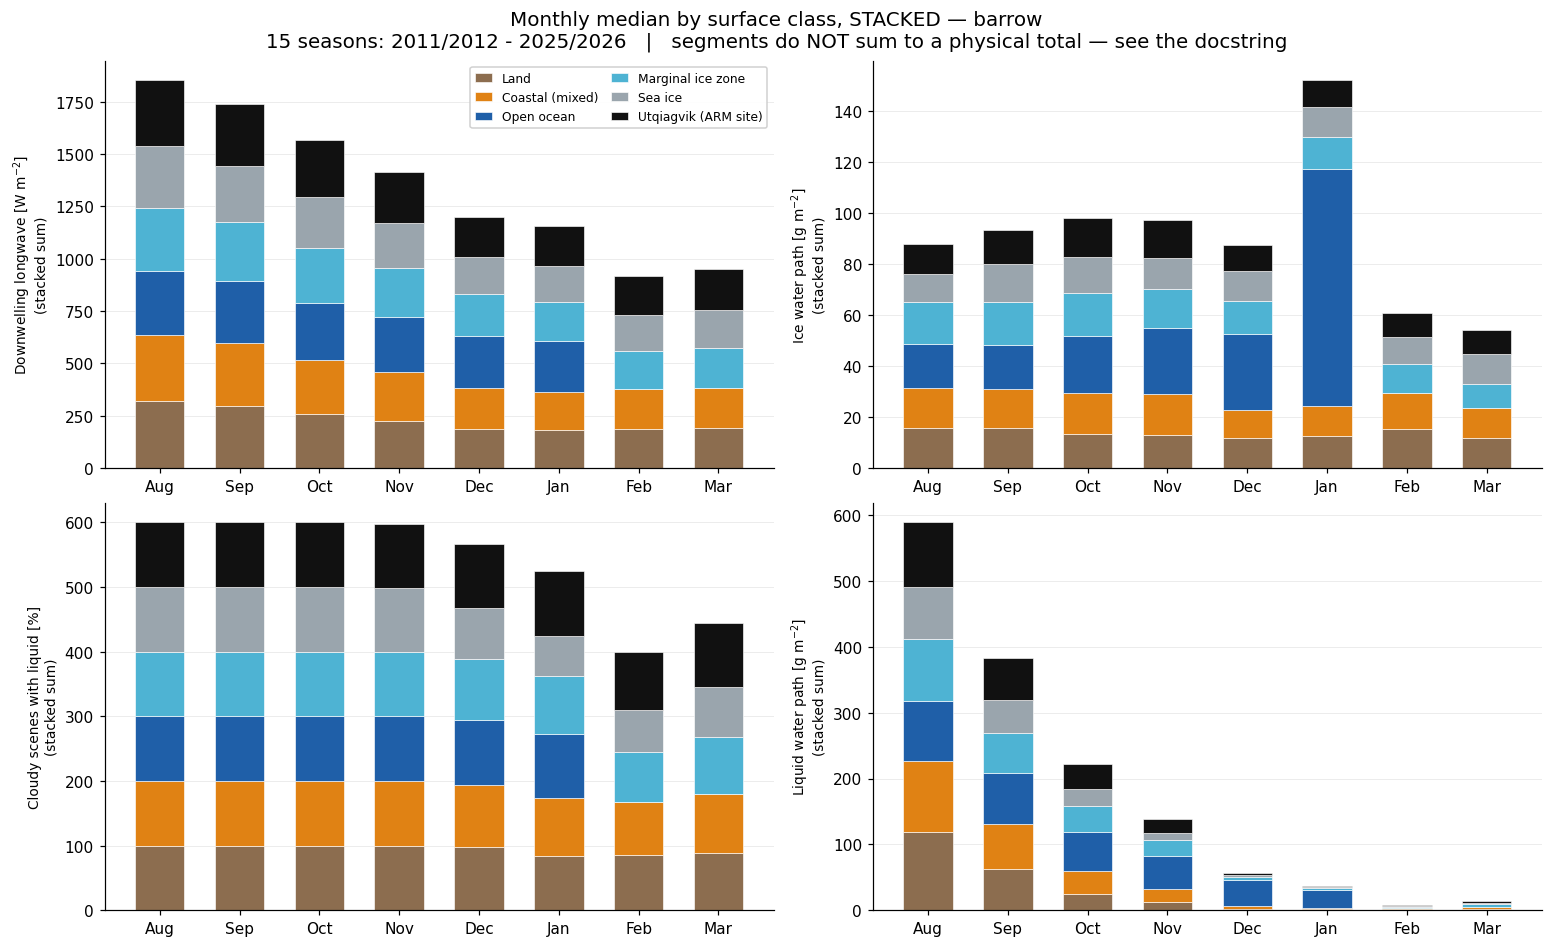

In [9]:
sct.fig_monthly_stacked(A, out_dir=SAVE_DIR);

### One slot per month, six values on a shared axis

What the stacked view was reaching for — six comparable numbers in one slot per
month — without the false claim that they add up. Each month is a single tick,
the six markers sit at their actual values, and both within-month and
across-month comparisons read straight off the y axis.

This is the one to use if the grouped bars feel too busy.

  -> figures/SurfaceClass/barrow_surfaceclass_monthly_dots_mean2011-2025.png


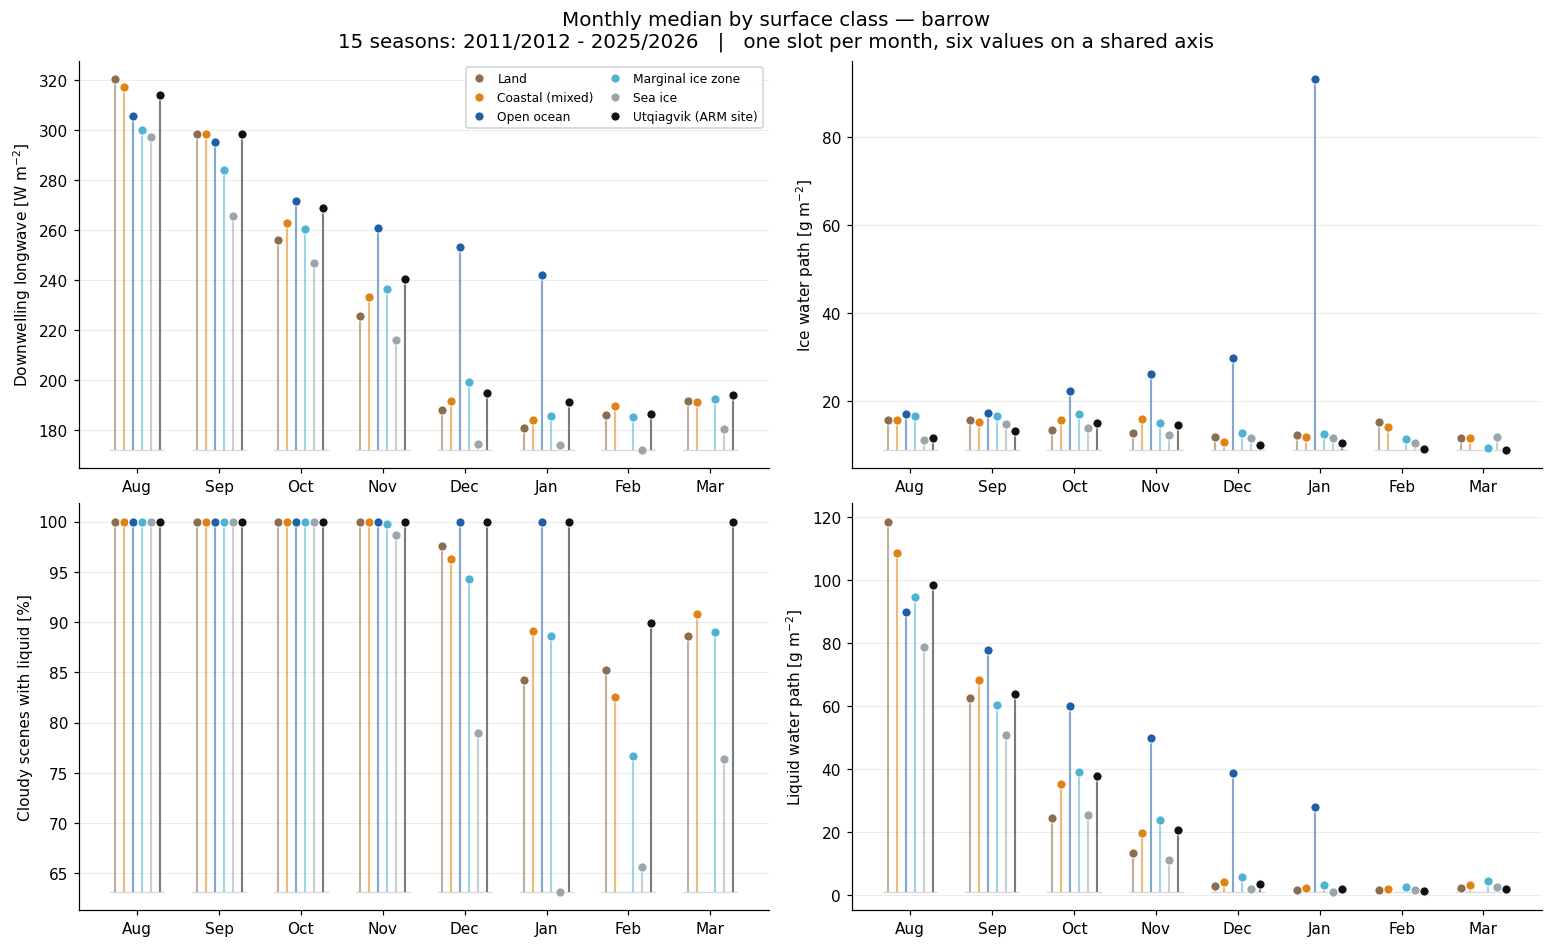

In [10]:
sct.fig_monthly_dots(A, out_dir=SAVE_DIR);

### The numbers behind the figures

`monthly_medians` returns `(months, {quantity: array[month, series]})` with the
series axis in `CLASS_ORDER` order followed by the ARM site, if you would rather
tabulate than plot.

In [11]:
import calendar
import numpy as np

months, med = sct.monthly_medians(A)
style = sct._series_style(A)

for q in sorted(sct.QUANTITIES):
    label, units, _ = sct.QUANTITIES[q]
    print(f"\n{label} [{units}]")
    print("       " + "".join(f"{lab[:11]:>13}" for lab, _ in style))
    for mi, m in enumerate(months):
        print(f"  {calendar.month_abbr[m]:<5}"
              + "".join(f"{v:>13.2f}" for v in med[q][mi]))


Downwelling longwave [W m$^{-2}$]
                Land  Coastal (mi   Open ocean  Marginal ic      Sea ice  Utqiagvik (
  Aug         320.13       317.16       305.52       299.79       296.95       313.91
  Sep         298.28       298.24       295.23       284.02       265.57       298.19
  Oct         255.99       262.66       271.37       260.48       246.90       268.88
  Nov         225.60       233.24       260.96       236.47       216.07       240.30
  Dec         188.31       191.87       253.02       199.42       174.43       194.85
  Jan         180.81       183.95       242.14       185.86       174.30       191.30
  Feb         186.15       189.56          nan       185.33       172.36       186.59
  Mar         191.63       191.39          nan       192.59       180.38       194.04

Ice water path [g m$^{-2}$]
                Land  Coastal (mi   Open ocean  Marginal ic      Sea ice  Utqiagvik (
  Aug          15.72        15.71        17.09        16.60        11.15    

## Redraw everything

Same set the command-line run writes with `--variable all`.

  -> figures/SurfaceClass/barrow_surfaceclass_dlr_mean2011-2025.png
  -> figures/SurfaceClass/barrow_surfaceclass_lwp_mean2011-2025.png
  -> figures/SurfaceClass/barrow_surfaceclass_iwp_mean2011-2025.png
  -> figures/SurfaceClass/barrow_surfaceclass_liquid_fraction_mean2011-2025.png


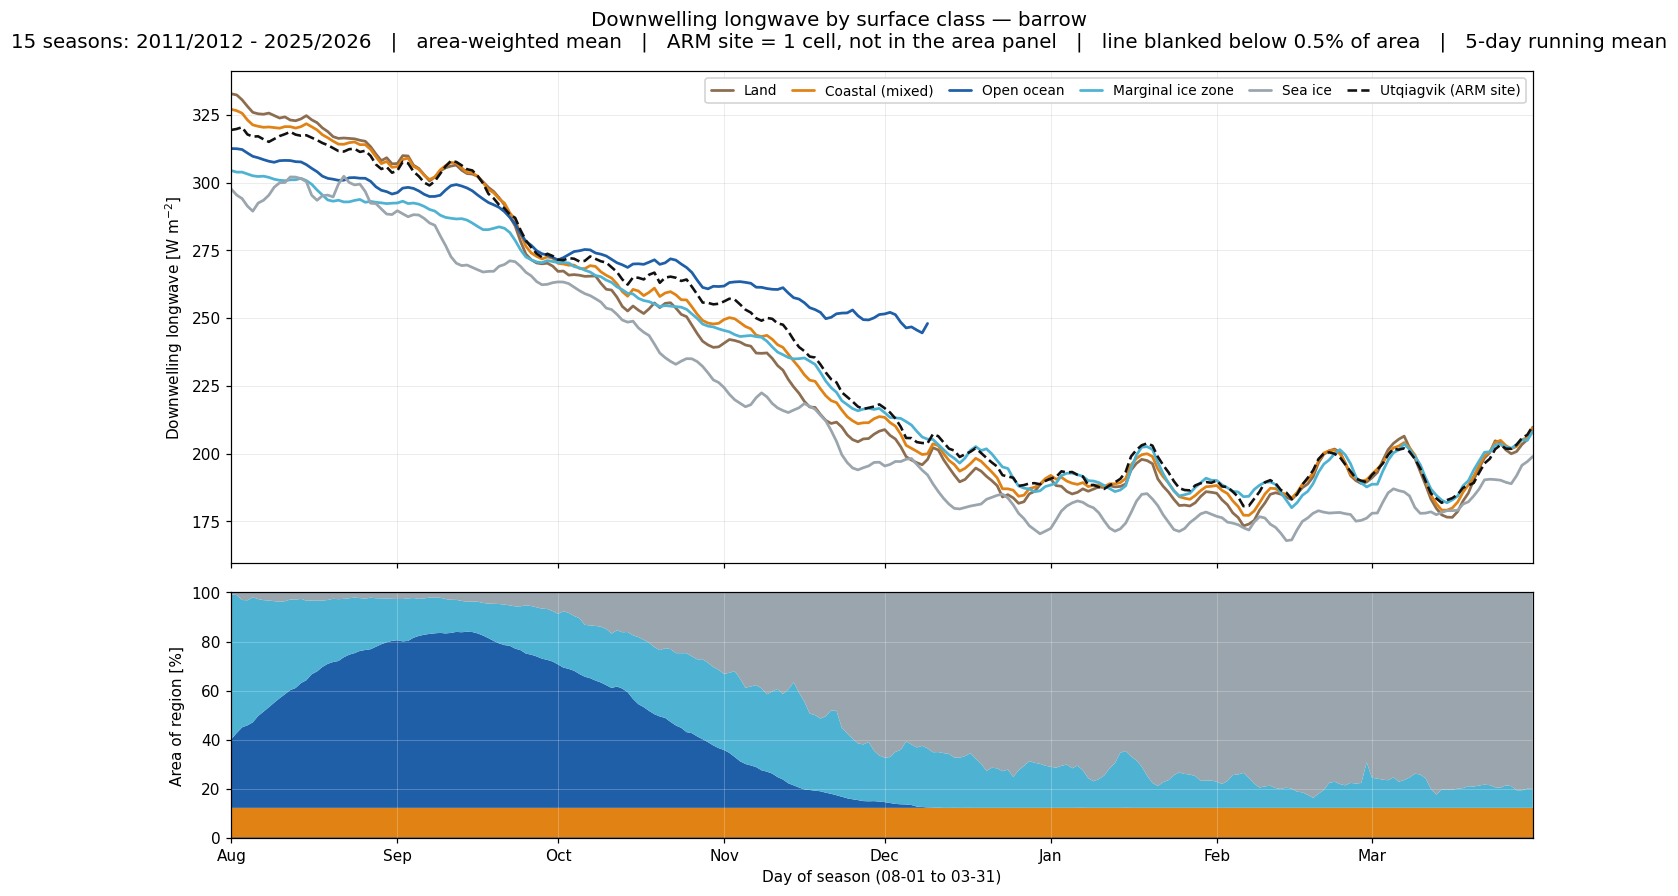

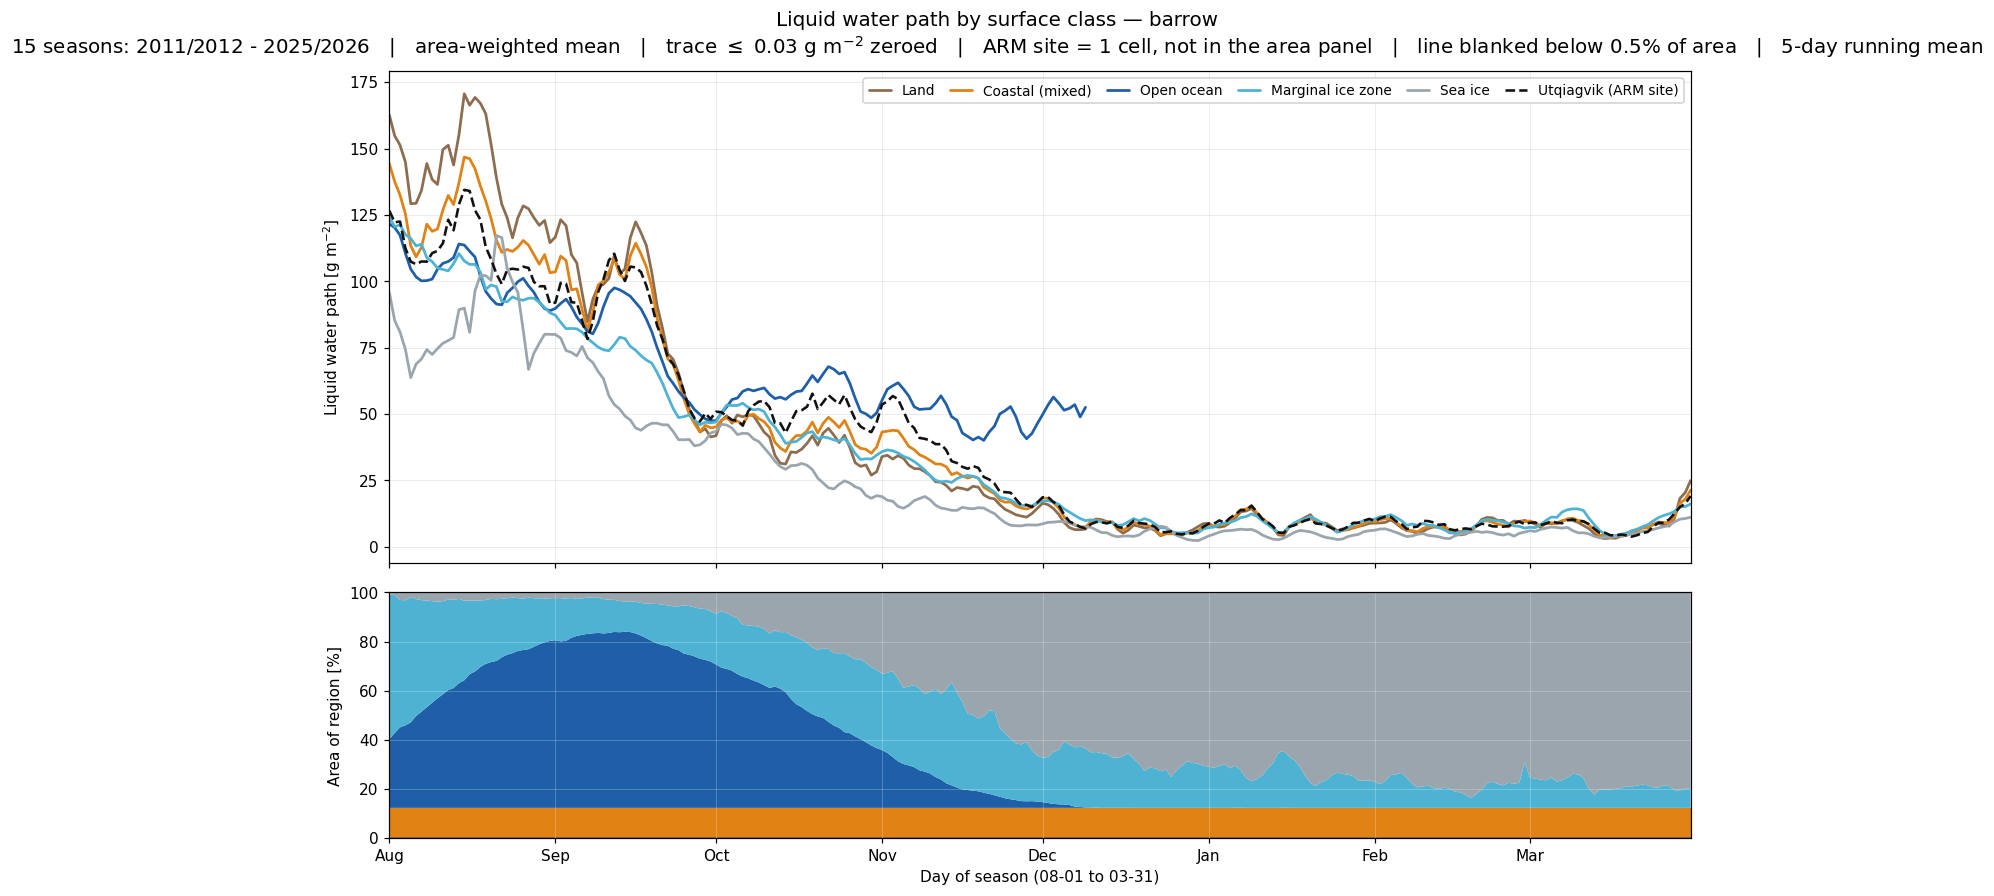

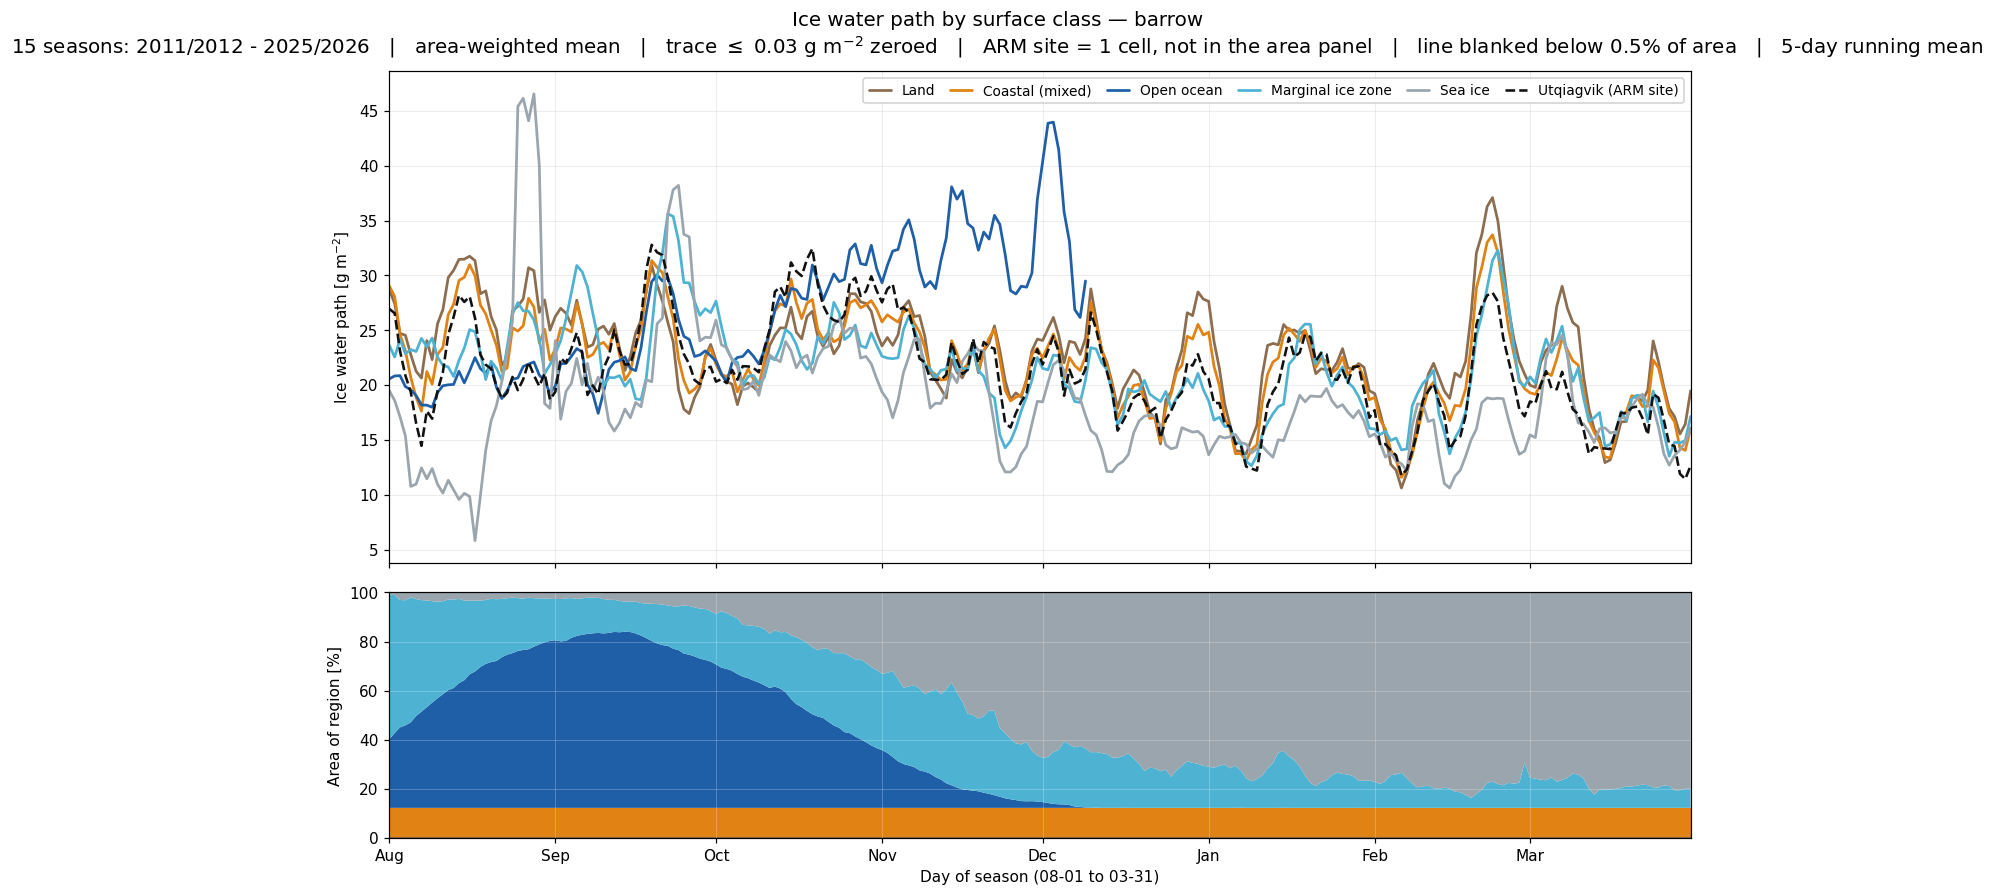

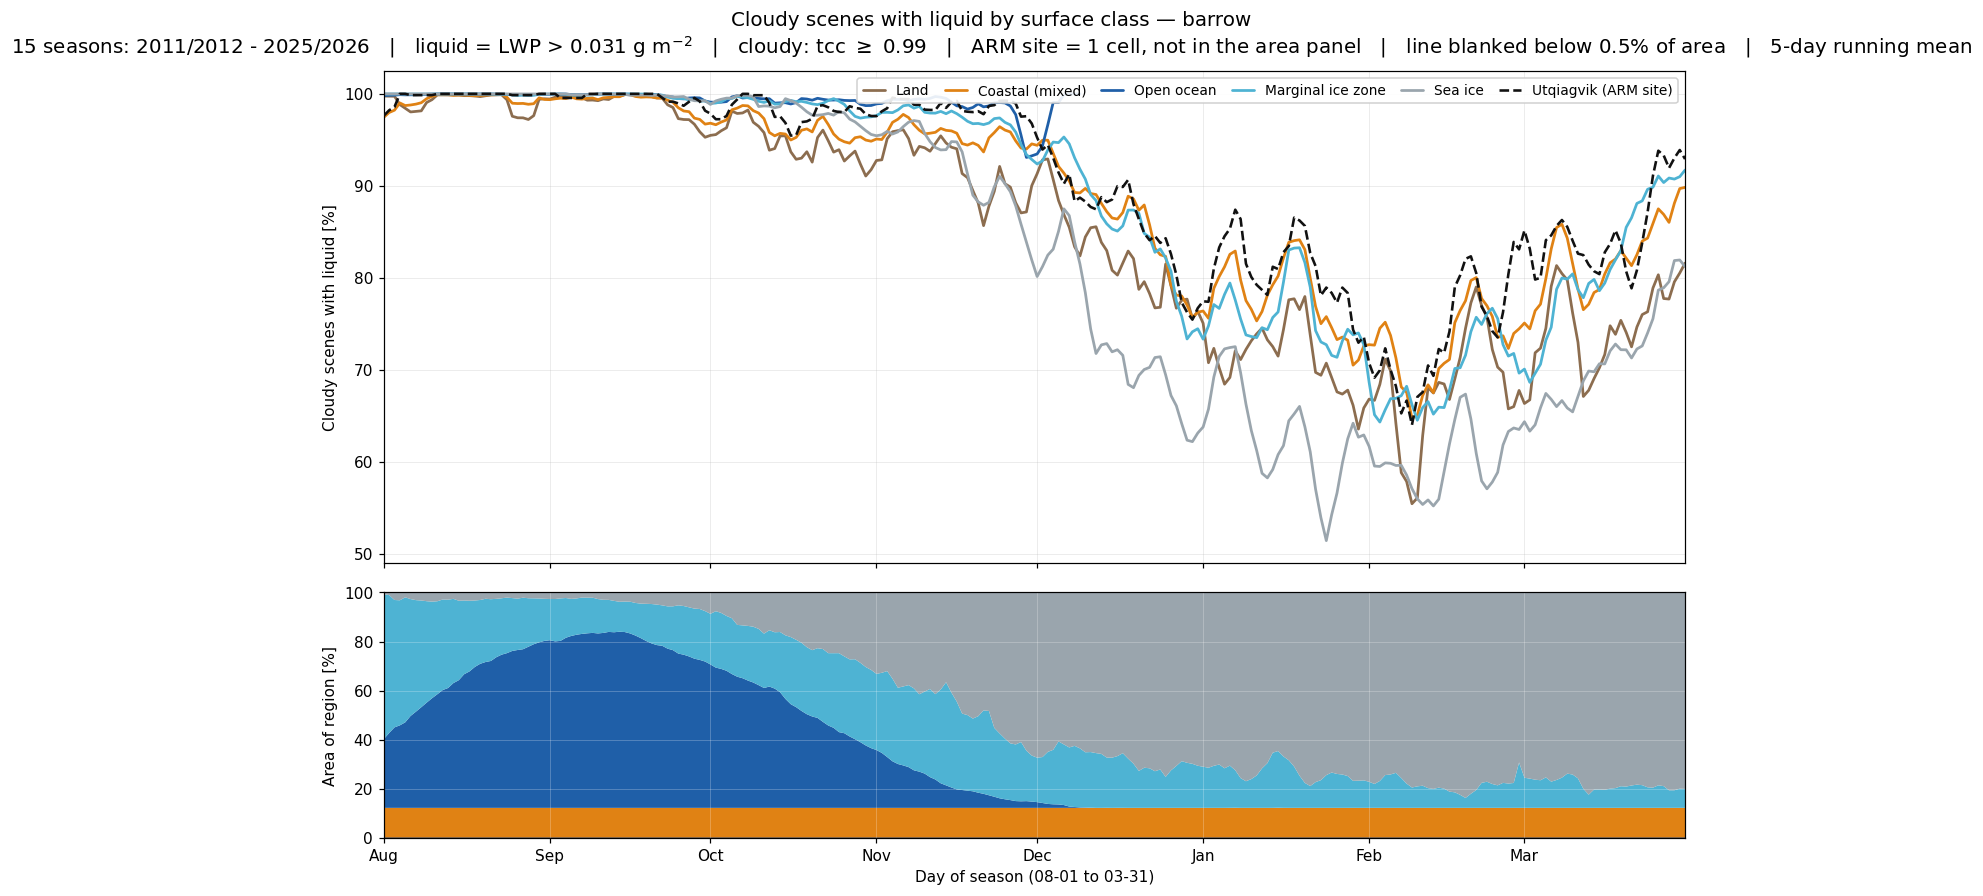

In [12]:
for fn in sct.ALL_FIGURES:
    fn(A, out_dir=SAVE_DIR);

## Changing options

Anything that alters what is loaded, classified, or accumulated — region, years,
season window, the siconc/lsm class boundaries, `lwp_threshold`,
`trace_threshold`, `min_cloud_fraction` — needs a fresh `prepare()`:

```python
A_wide = sct.prepare(region="barrow", years=(2019, 2020),
                     open_ocean_max_siconc=0.15)
sct.fig_dlr(A_wide)
```

Options that only affect drawing can be changed on the existing `A` without
reloading, since the figures read them at draw time:

```python
A.args.smooth = 7            # 7-day running mean
A.args.area_style = "lines"  # instead of a stacked area panel
A.args.min_class_area = 2.0  # blank classes below 2% of the domain
sct.fig_dlr(A)
```

Any quantity by name, if you prefer a loop to the four named helpers:

```python
sct.figure(A, "liquid_fraction")
```

## The ARM site cell

The cell is chosen by nearest neighbour on the ERA5 grid, with longitudes
compared on a signed -180..180 axis so a 0..360 archive matches too. At ERA5's
0.25° resolution the cell is roughly 28 km north-south, so the facility can
sit up to ~0.125° from the centre of the cell representing it; `print_report`
gives the exact offset.

Two things worth keeping in mind when comparing against ARM observations:

- **It is a 0.25° area mean, not a point.** Utqiaġvik is on the coast,
  so the cell mixes land and ocean, and its ERA5 surface properties are a blend
  of both. The report tells you which class it lands in.
- **`tcc` and the condensate paths are instantaneous hourly samples**, whereas
  ARM instruments sample far faster. The comparison is fair for occupancy
  fractions and for means, not for event durations.

To move the site (a different ARM facility, say), pass explicit coordinates to
`sct.site_cell_mask`, or edit `SITE_LAT` / `SITE_LON` in the module.